# Segmentação de letras - Parte 2
Em seguida, aplicaremos o algoritmo de segmentação em imagens que são pequenas e que aparentemente já passaram por algum tipo de processamento: fundo é claramente branco, mas as letras apresentam algum tipo de imperfeição.

## Abordagem: componentes conectados

Importando bibliotecas

In [1]:
import cv2 as cv
from skimage import measure
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
import math
import os
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

Função `plot_all(str directory)`: exibe todas as imagens que estão no diretório-raiz `directory`.

In [2]:
def plot_all(directory):
    # Extensões de imagem válidas
    valid_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

    # Coleta todos os caminhos de imagens (recursivamente)
    image_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if os.path.splitext(file)[1].lower() in valid_extensions:
                image_paths.append(os.path.join(root, file))

    # Aumente o número de colunas aqui
    n_cols = 5
    n_rows = -(-len(image_paths) // n_cols)  # arredonda pra cima

    # Ajuste do tamanho da figura
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2 * n_rows))
    axes = axes.flatten() if len(image_paths) > 1 else [axes]

    # Define tamanho máximo de exibição
    max_size = (600, 600)

    for ax, img_path in zip(axes, image_paths):
        try:
            # Abre imagem e corrige orientação EXIF automaticamente
            img = Image.open(img_path)
            img = ImageOps.exif_transpose(img)
            img = img.convert("RGB")

            # Redimensiona mantendo proporção
            img.thumbnail(max_size)

            # Exibe imagem
            ax.imshow(img)
            ax.set_title(os.path.basename(img_path), fontsize=8)
            ax.axis("off")
        except Exception as e:
            ax.set_title(f"Erro ao carregar:\n{os.path.basename(img_path)}", fontsize=8)
            ax.axis("off")

    # Remove subplots vazios
    for i in range(len(image_paths), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


## Etapa 1: Pré-processamento

Pasta raiz em `INPUT_ROOT_FOLDER`, pasta destino em `OUTPUT_ROOT_FOLDER`, com as transformações resultantes do pré-processamento.

In [3]:
INPUT_ROOT_FOLDER = 'data_2'
OUTPUT_ROOT_FOLDER = 'data_2/interim'

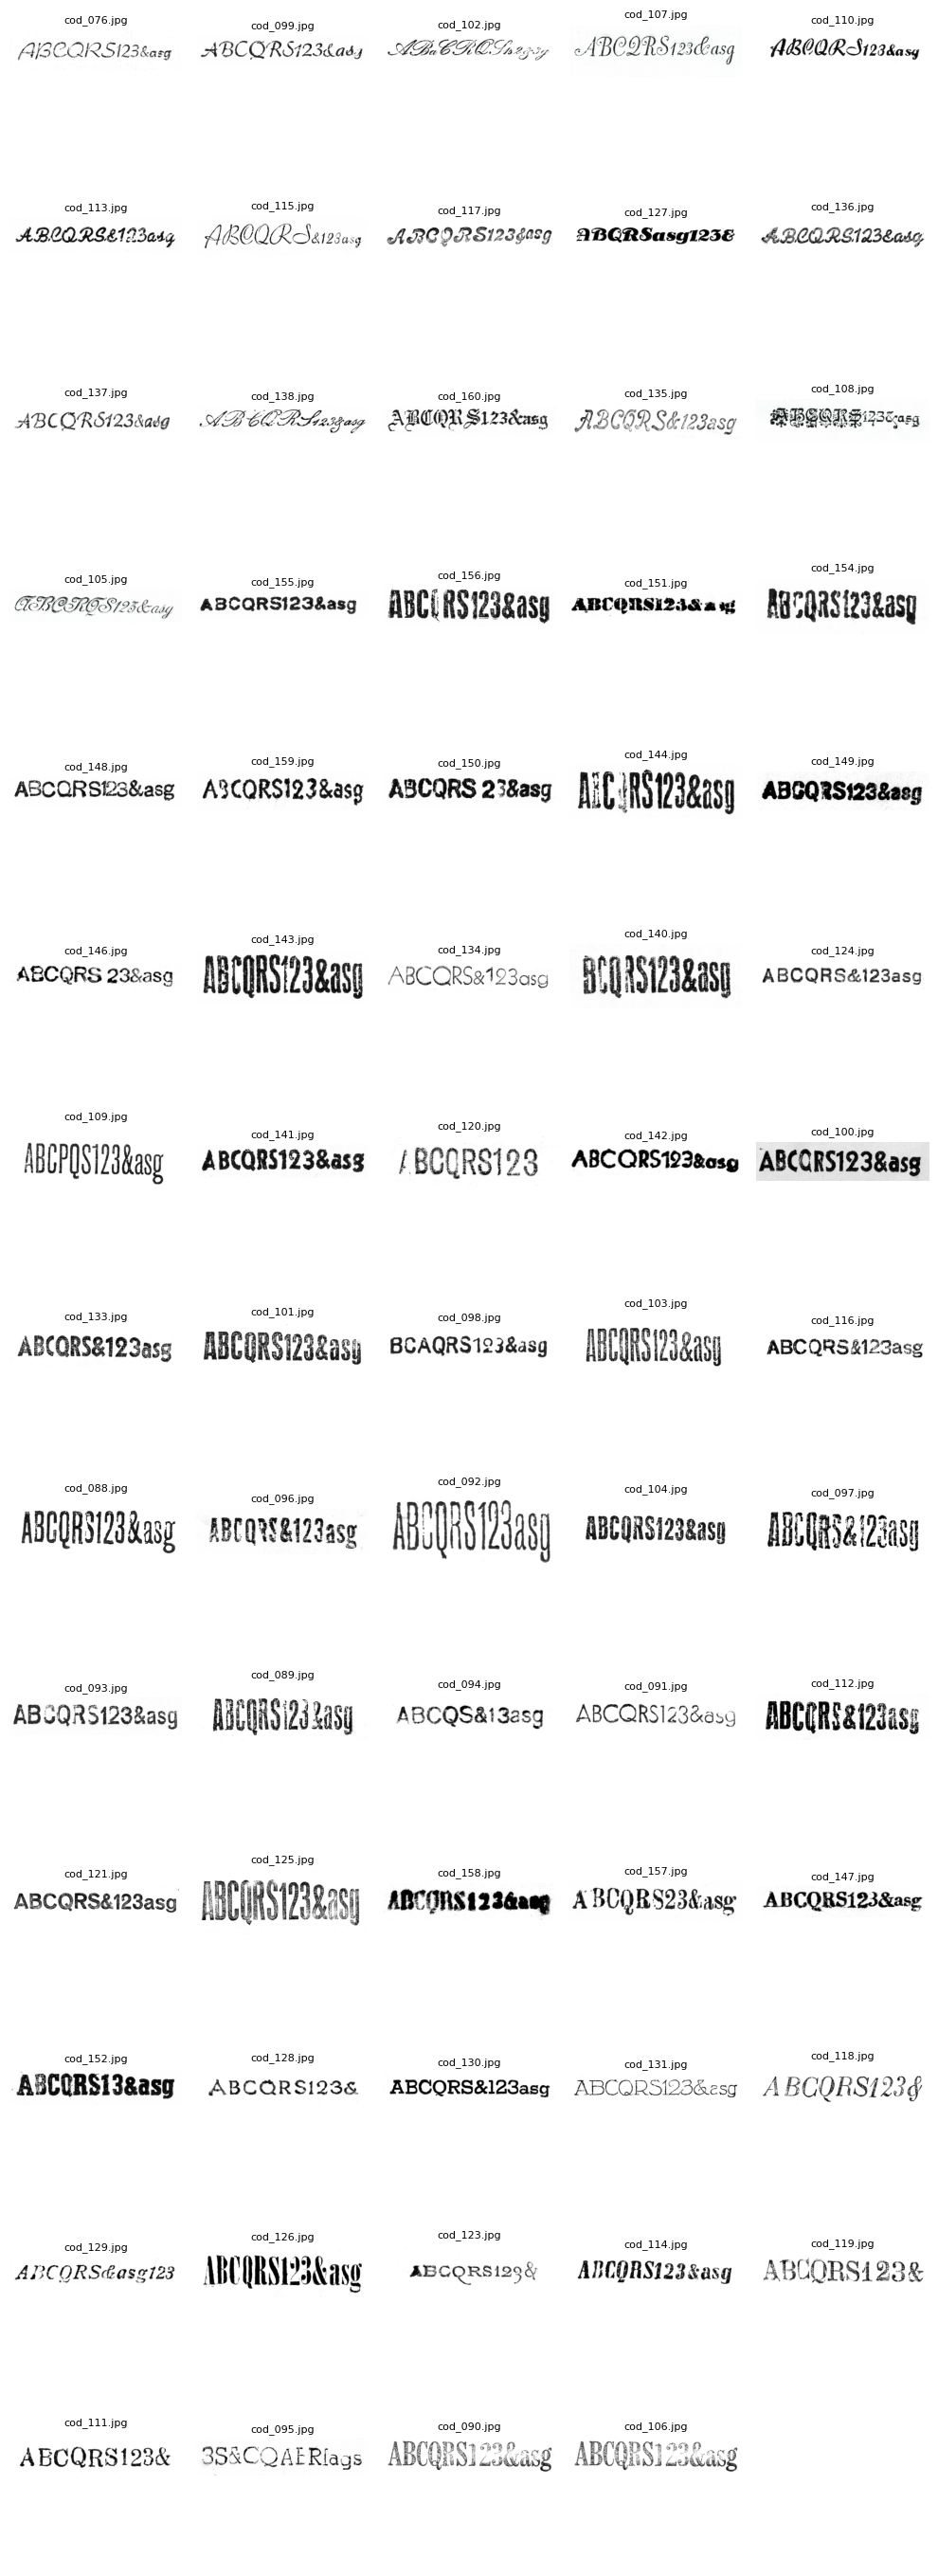

In [4]:
plot_all(f'{INPUT_ROOT_FOLDER}/raw')

### 1.1: Remoção de ruído e binarização
Para remoção de ruído, será aplicado filtro de mediana sobre as imagens, de kernel tamanho 15x15, para remoção de ruído 'sal e pimenta', seguido de binarização simples. Valores menores ou iguais a 127 são reduzidos a 0 (preto - idealmente, as letras), enquanto valores maiores que 127 são mudados a 255 (branco - idealmente, o fundo).

In [5]:
for current_path, subdirectories, files in os.walk(f'{INPUT_ROOT_FOLDER}/raw'):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            style_name = os.path.basename(current_path)
            output_image_dir = os.path.join(f'{OUTPUT_ROOT_FOLDER}/binarized', style_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"-> Style: '{style_name}', Image Code: '{image_base_name}'")
            print(f"-> Output will be saved to: {output_image_dir}")

            img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  -> Error loading image. Skipping...")
                continue
            
            blur = cv.medianBlur(img, 15)
             
            _,binarized = cv.threshold(img,127,255,cv.THRESH_BINARY)

            cv.imwrite(f'{output_image_dir}/{image_base_name}.png', binarized)

            print("-> Saved at ", output_image_dir)


Processing image: data_2/raw/escritural/cod_076.jpg
-> Style: 'escritural', Image Code: 'cod_076'
-> Output will be saved to: data_2/interim/binarized/escritural
-> Saved at  data_2/interim/binarized/escritural

Processing image: data_2/raw/escritural/cod_099.jpg
-> Style: 'escritural', Image Code: 'cod_099'
-> Output will be saved to: data_2/interim/binarized/escritural
-> Saved at  data_2/interim/binarized/escritural

Processing image: data_2/raw/escritural/cod_102.jpg
-> Style: 'escritural', Image Code: 'cod_102'
-> Output will be saved to: data_2/interim/binarized/escritural
-> Saved at  data_2/interim/binarized/escritural

Processing image: data_2/raw/escritural/cod_107.jpg
-> Style: 'escritural', Image Code: 'cod_107'
-> Output will be saved to: data_2/interim/binarized/escritural
-> Saved at  data_2/interim/binarized/escritural

Processing image: data_2/raw/escritural/cod_110.jpg
-> Style: 'escritural', Image Code: 'cod_110'
-> Output will be saved to: data_2/interim/binarized/

Exibindo os resultados da binarização + filtragem:

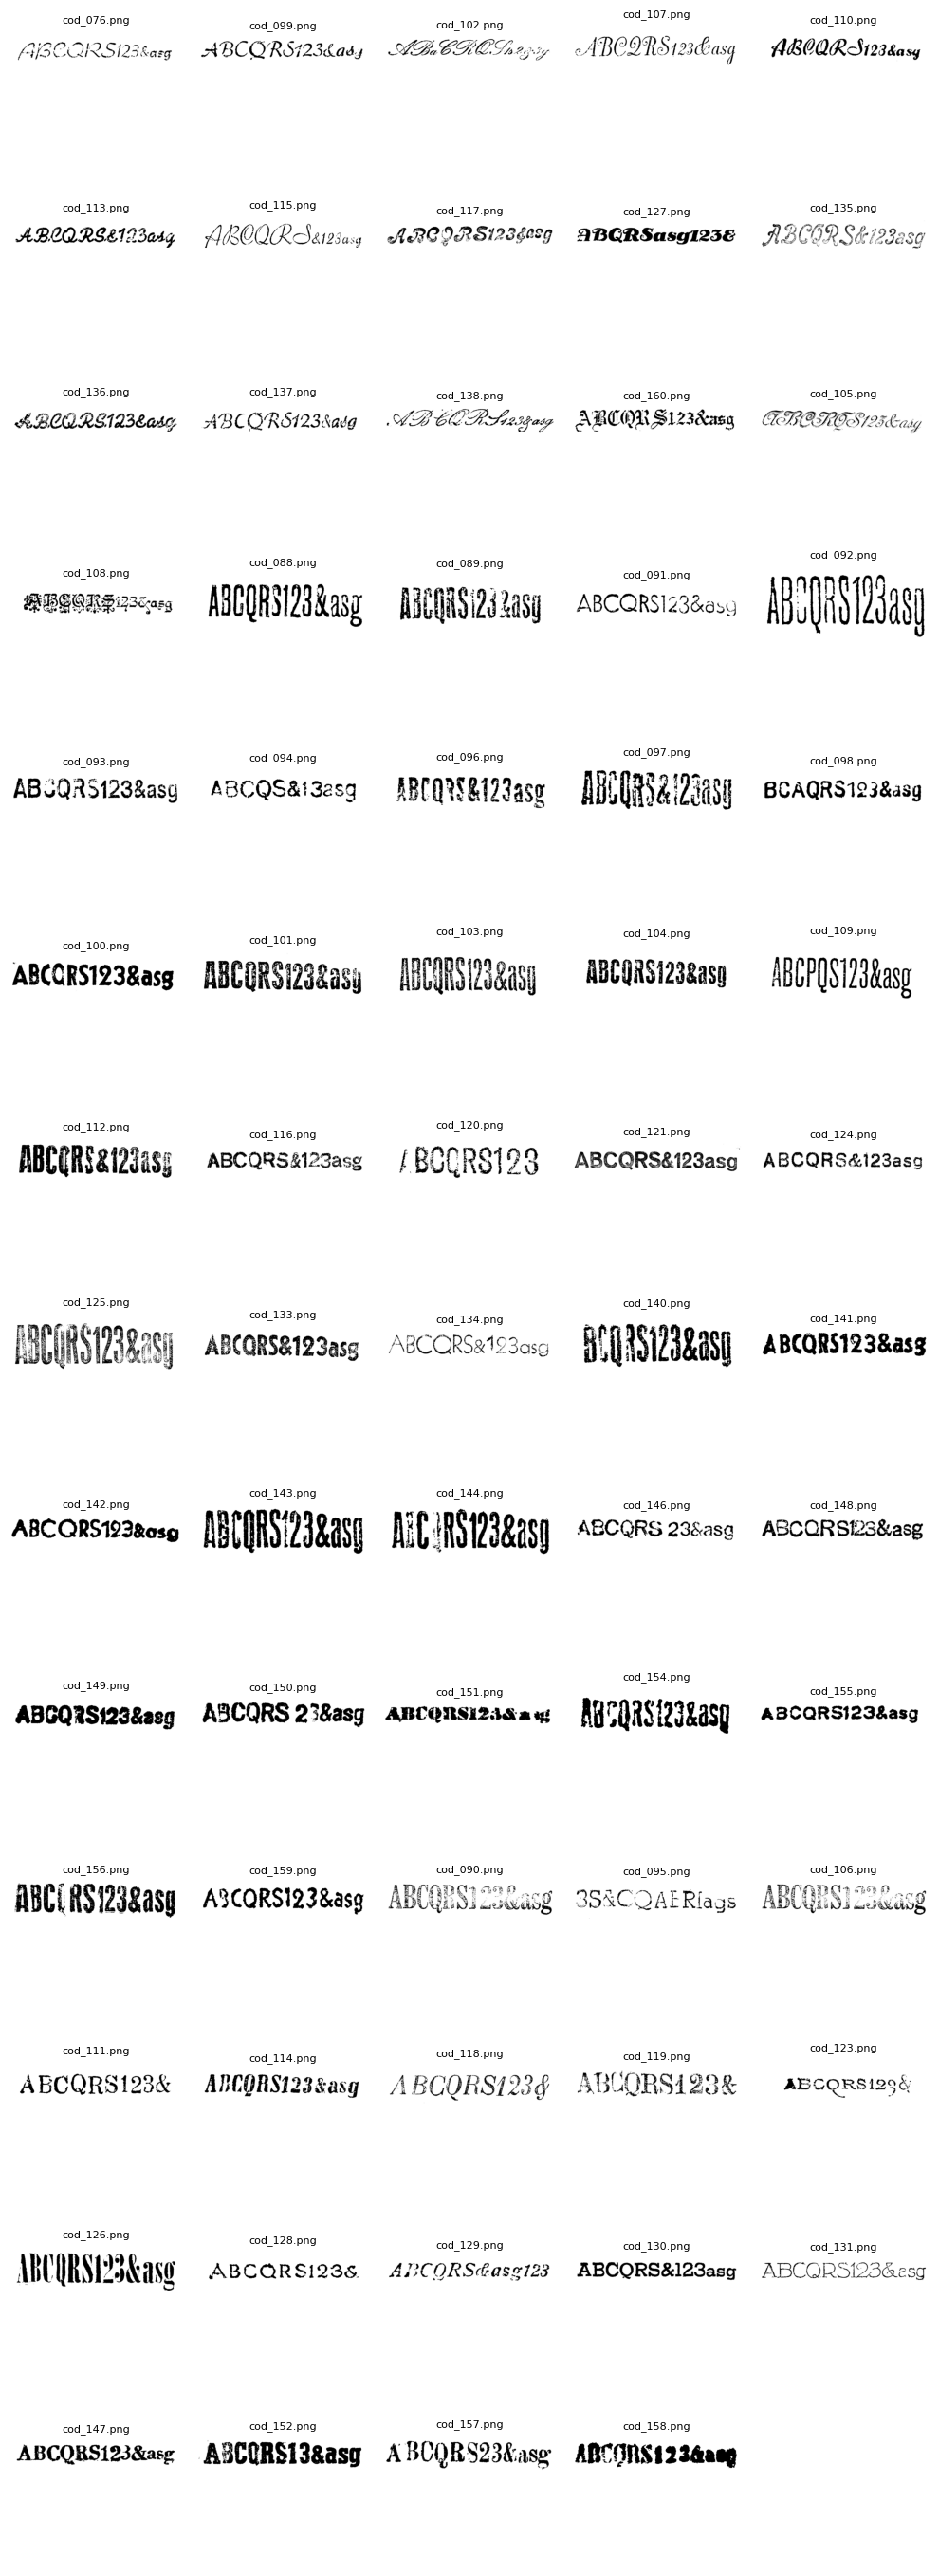

In [6]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/binarized')

### 1.2: Fechamento morfológico
O fechamento morfológico será aplicado para juntar componentes de letras que, por razões diversas (falhas de impressão, iluminação não uniforme, etc.) podem estar desconectadas após a binarização, o que afeta a segmentação que será feita em etapa futura. 

In [ ]:
kernel = np.ones((21,21), np.uint8)

for current_path, subdirectories, files in os.walk(f'{OUTPUT_ROOT_FOLDER}/binarized'):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            style_name = os.path.basename(current_path)
            output_image_dir = os.path.join(f'{OUTPUT_ROOT_FOLDER}/morph_closed', style_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"-> Style: '{style_name}', Image Code: '{image_base_name}'")
            print(f"-> Output will be saved to: {output_image_dir}")

            img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE) 
            
            if img is not None:
                img_inverted = 255 - img
                closing_result = cv.morphologyEx(img_inverted, cv.MORPH_CLOSE, kernel)
                result = 255 - closing_result
                
                cv.imwrite(f'{output_image_dir}/{image_base_name}.png', result)

                print("Saved at ", output_image_dir)


Processing image: data_2/interim/binarized/escritural/cod_076.png
-> Style: 'escritural', Image Code: 'cod_076'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_099.png
-> Style: 'escritural', Image Code: 'cod_099'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_102.png
-> Style: 'escritural', Image Code: 'cod_102'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_107.png
-> Style: 'escritural', Image Code: 'cod_107'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_110.png
-> Style: 'escrit

**Por que o fechamento morfológico não irá funcionar para as imagens desse grupo, como funcionaram para o grupo anterior?**

As imagens possuem tamanho reduzido quando comparadas ao grupo **data_1**. Portanto, aparecerão assim após o pré-processamento, com caracteres distintos conectados entre si:

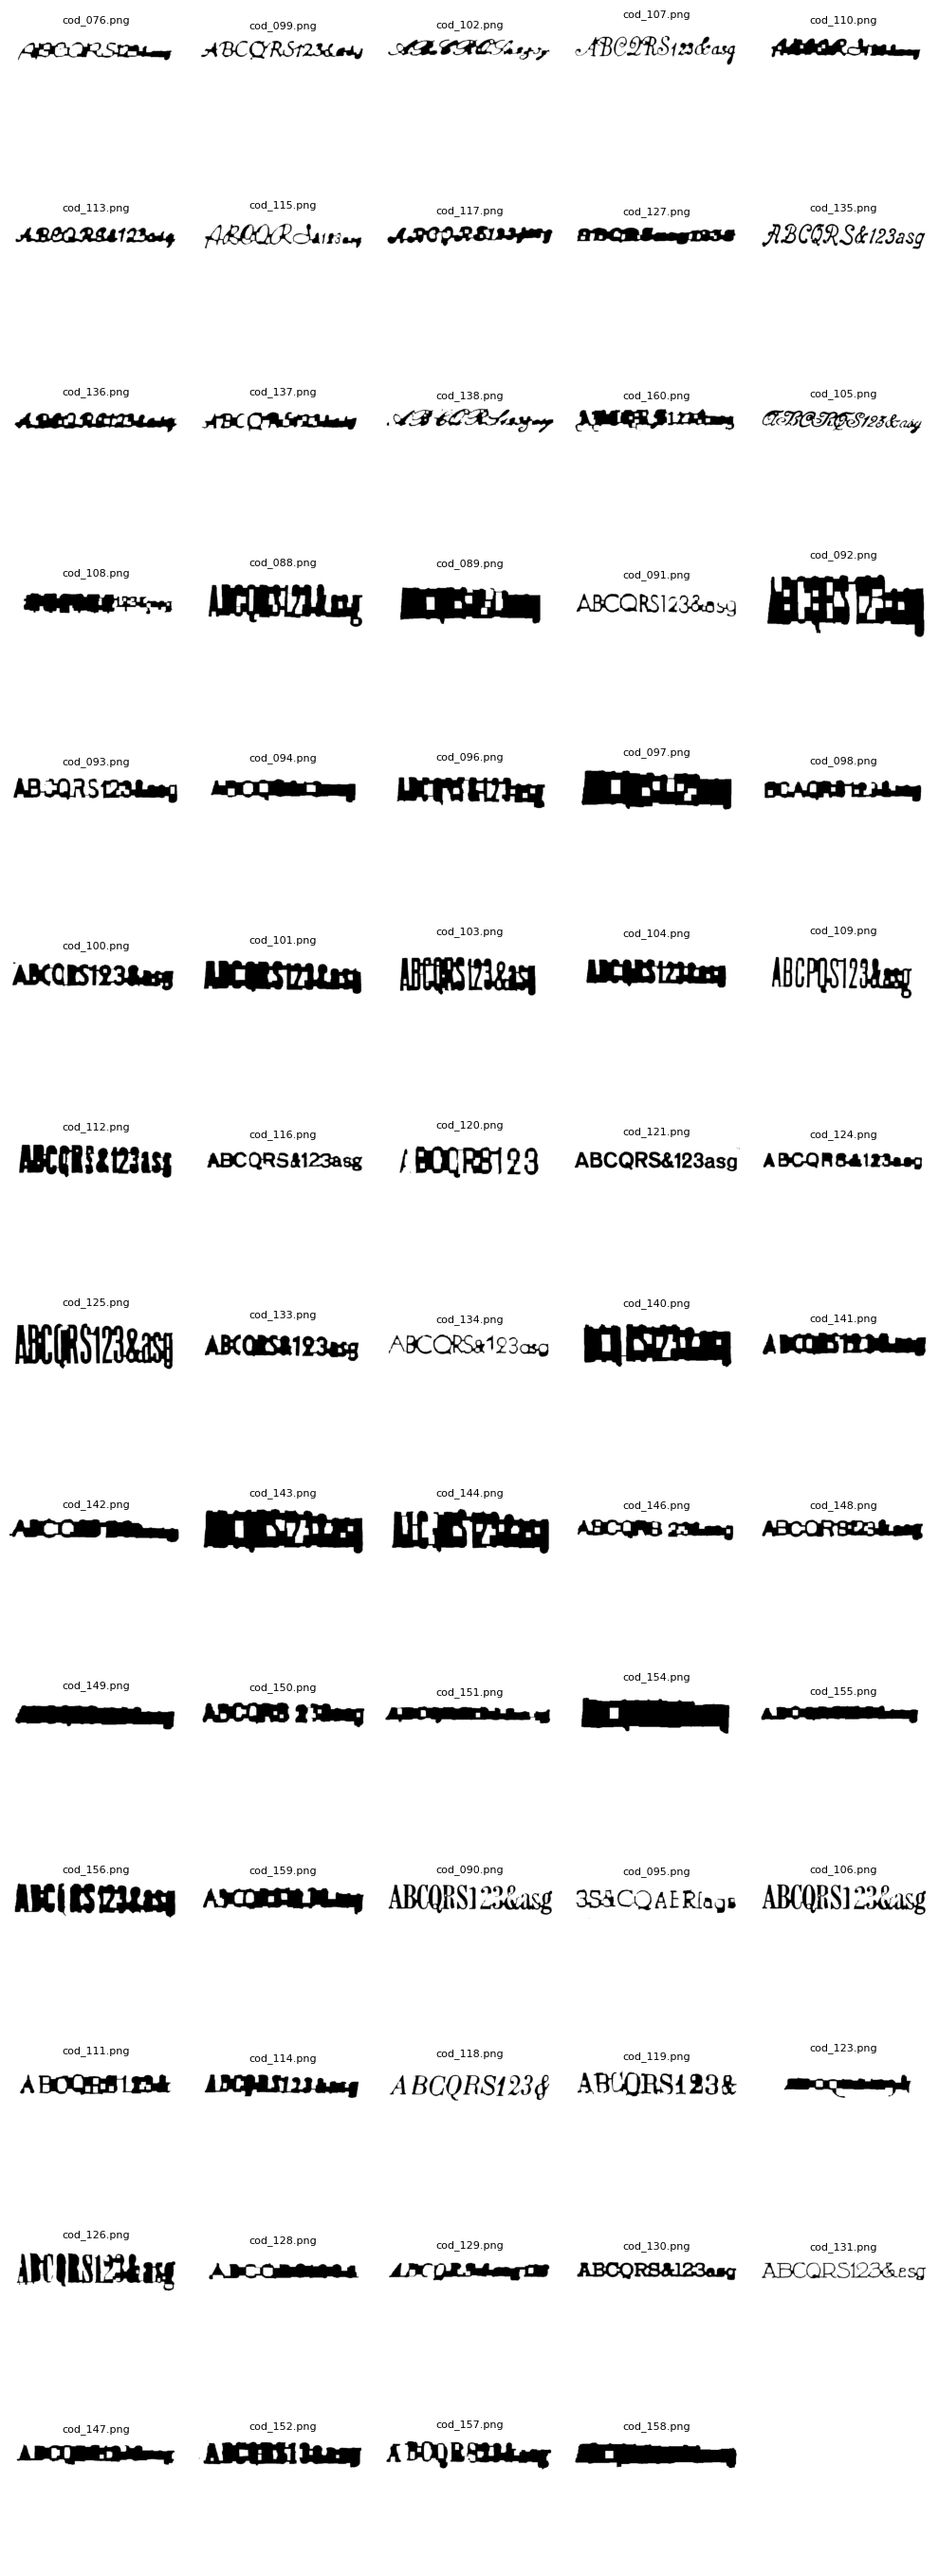

In [8]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/morph_closed')

... o que afetará a segmentação por componentes conectados. Portanto, vamos reduzir o tamanho do kernel morfológico para, por exemplo, 7x7. 

In [10]:
kernel = np.ones((7,7), np.uint8)

for current_path, subdirectories, files in os.walk(f'{OUTPUT_ROOT_FOLDER}/binarized'):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            style_name = os.path.basename(current_path)
            output_image_dir = os.path.join(f'{OUTPUT_ROOT_FOLDER}/morph_closed', style_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"-> Style: '{style_name}', Image Code: '{image_base_name}'")
            print(f"-> Output will be saved to: {output_image_dir}")

            img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE) 
            
            if img is not None:
                img_inverted = 255 - img
                closing_result = cv.morphologyEx(img_inverted, cv.MORPH_CLOSE, kernel)
                dilation = cv.dilate(closing_result, kernel, iterations=1)
                result = 255 - closing_result
                
                cv.imwrite(f'{output_image_dir}/{image_base_name}.png', result)

                print("Saved at ", output_image_dir)


Processing image: data_2/interim/binarized/escritural/cod_076.png
-> Style: 'escritural', Image Code: 'cod_076'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_099.png
-> Style: 'escritural', Image Code: 'cod_099'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_102.png
-> Style: 'escritural', Image Code: 'cod_102'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_107.png
-> Style: 'escritural', Image Code: 'cod_107'
-> Output will be saved to: data_2/interim/morph_closed/escritural
Saved at  data_2/interim/morph_closed/escritural

Processing image: data_2/interim/binarized/escritural/cod_110.png
-> Style: 'escrit

Novo resultado do fechamento morfológico:

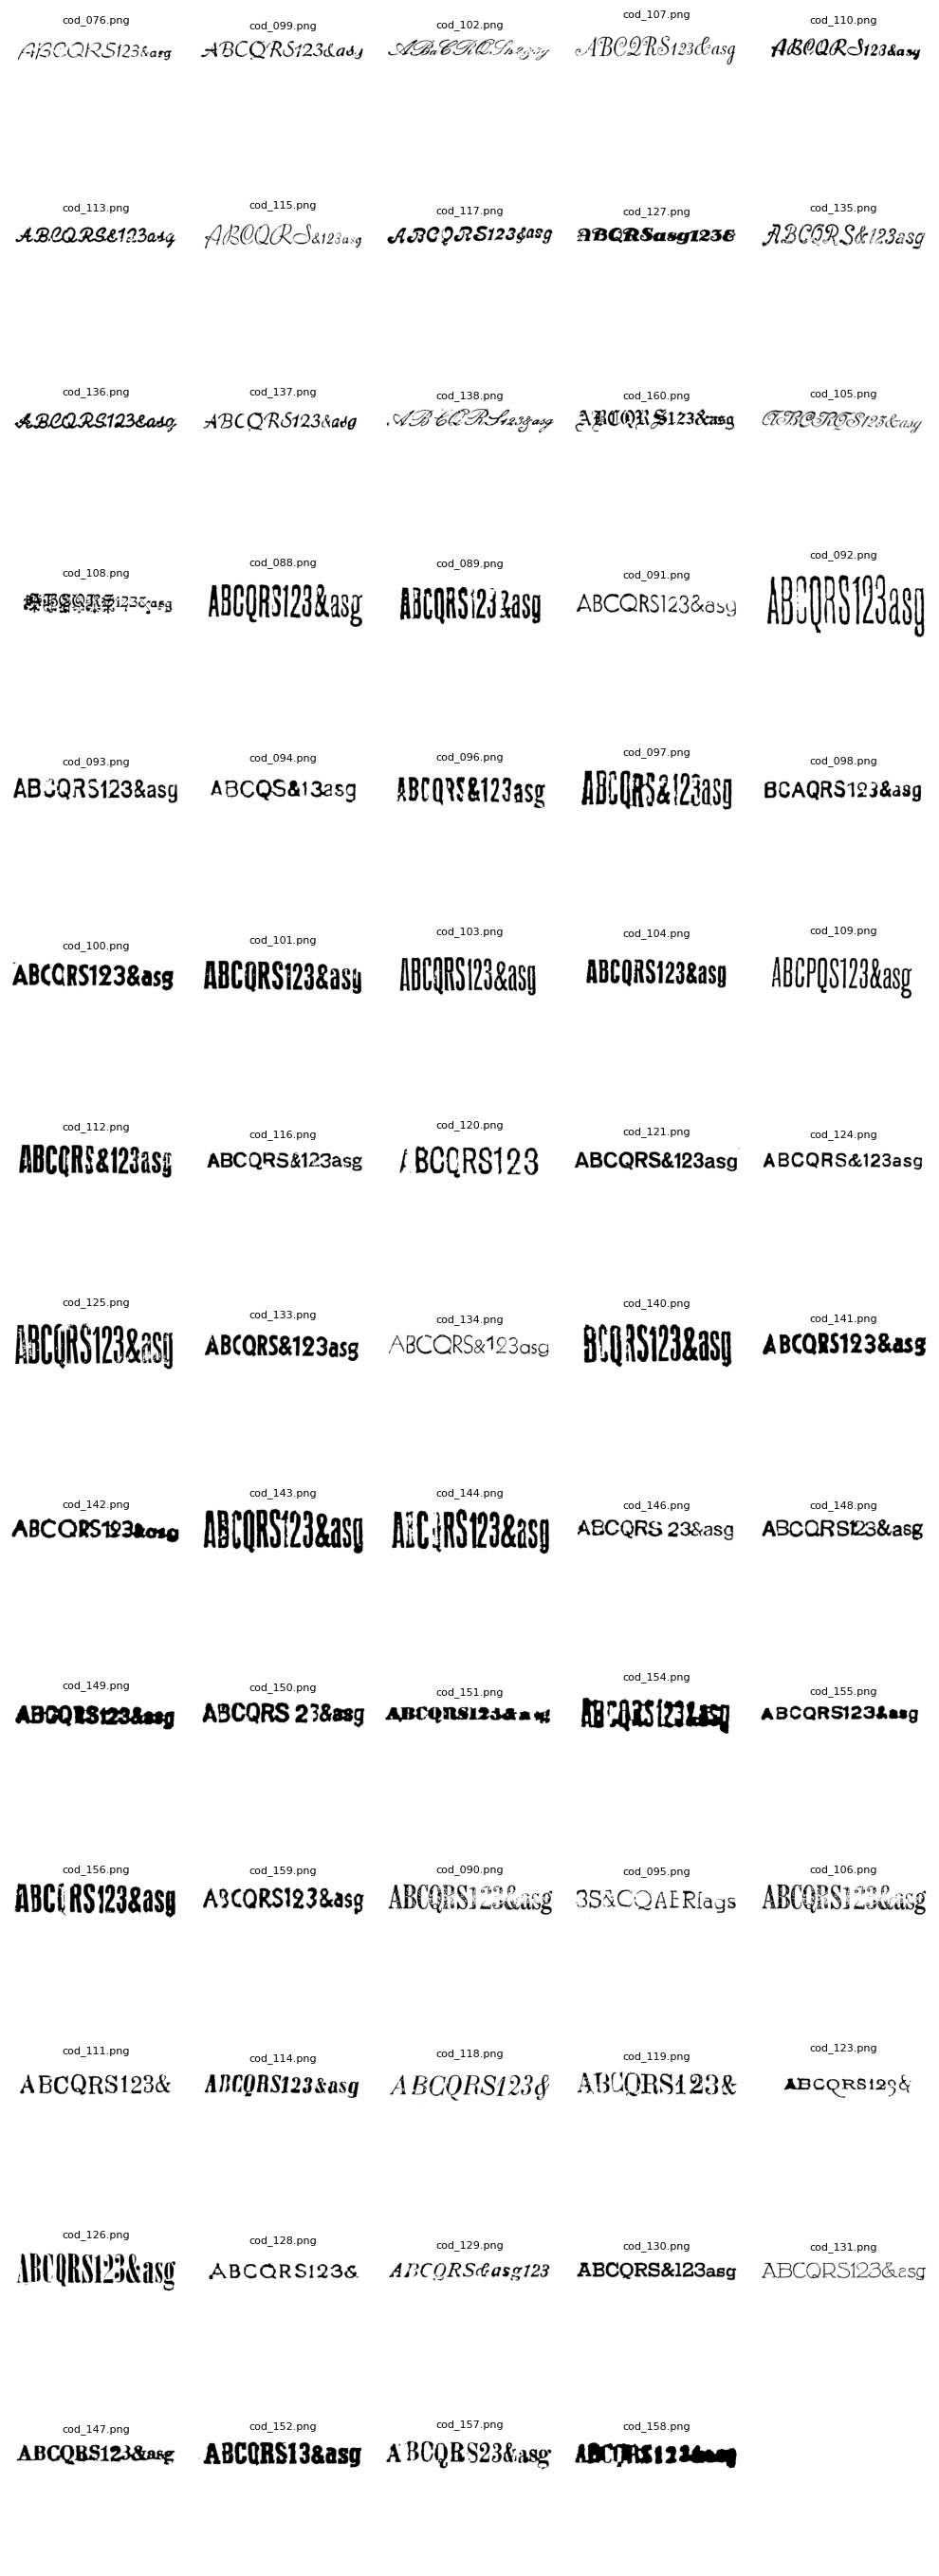

In [11]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/morph_closed')

... com caracteres visualmente separáveis e distinguíveis.

## Etapa 2: Segmentação utilizando componentes conexas
A segmentação é feita com base em componentes conexas. São consideradas componentes conexas pixels de valores distintos do fundo (de valor zero) que estão conectadas por vizinhança-8 (cima, baixo, esquerda, direita e diagonais). Cada componente é considerada, portanto, um caracter distinto.

Como dito anteriormente, estamos interessados apenas nos retângulos delimitadores das letras. Com os limites de cada letra em mãos, os recortes serão obtidos **das imagens originais** (localizados nas pastas `raw`).

Utilizamos, para tanto, o módulo `measure` da biblioteca `Scikit-image`. Esse módulo contém duas funções-chave: `measure.label`, que encontra as componentes conexas e estabelece rótulos para cada uma (0 para o fundo, e 1, 2, 3... para cada componente encontrada), e `measure.regionprops`, que extrai características quantitativas de cada objeto encontrado (inclusive delimitações da bounding box) e as guarda em um dicionário indexado pelo rótulo do objeto (ref.: [Documentação skimage.measure](https://scikit-image.org/docs/0.25.x/api/skimage.measure.html))

Trocamos as pastas de origem e destino nesta etapa. `AUX_ROOT_FOLDER` consiste na pasta com as imagens transformadas. `INPUT_ROOT_FOLDER` contém as imagens originais. `OUTPUT_ROOT_FOLDER` conterá os recortes, a partir das imagens originais, das componentes conexas encontradas nas imagens transformadas.

In [12]:
AUX_ROOT_FOLDER = 'data_2/interim/morph_closed'
INPUT_ROOT_FOLDER = 'data_2/raw'
OUTPUT_ROOT_FOLDER = 'data_2/processed'

Abaixo, o código da segmentação. Veja que recortes cujo tamanho/número de pixels/área é menor que 100 não são salvos, como uma maneira de reduzir ruídos remanescentes.

In [13]:
for current_path, subdirectories, files in os.walk(INPUT_ROOT_FOLDER):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue

            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            style_name = os.path.basename(current_path)
            output_image_dir = os.path.join(OUTPUT_ROOT_FOLDER, style_name, image_base_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"  -> Style: '{style_name}', Image Code: '{image_base_name}'")
            print(f"  -> Output will be saved to: {output_image_dir}")

            original_img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE)
            if original_img is None:
                print(f"  -> Error loading image. Skipping...")
                continue
            
            img = cv.imread(os.path.join(AUX_ROOT_FOLDER, style_name, f'{image_base_name}.png'))
            
            labeled_img, num_labels = measure.label(img, connectivity=2, background=255, return_num=True)
            props = measure.regionprops(labeled_img)

            for i in range(0, num_labels):
                bbox = props[i].bbox

                cropped_letter = original_img[bbox[0]:bbox[3], bbox[1]:bbox[4]]
                print(np.size(cropped_letter))

                if np.size(cropped_letter) < 100:
                    continue

                output_filename = f"{image_base_name}_{i:03d}.png"
                output_path = os.path.join(output_image_dir, output_filename)

                cv.imwrite(output_path, cropped_letter)
            


Processing image: data_2/raw/escritural/cod_076.jpg
  -> Style: 'escritural', Image Code: 'cod_076'
  -> Output will be saved to: data_2/processed/escritural/cod_076
3082
7387
8460
8930
2162
6478
171
2079
1420
3195
816
8
1
1960
6
10
1
36
2700
1558
989
2090
3848
1330
1155
275
4
15
189
405
9
2

Processing image: data_2/raw/escritural/cod_099.jpg
  -> Style: 'escritural', Image Code: 'cod_099'
  -> Output will be saved to: data_2/processed/escritural/cod_099
15540
22278
14729
13622
17766
18720
6
1813
9804
9690
11934
2989
5850
5928
6956
6
1568
324
270

Processing image: data_2/raw/escritural/cod_102.jpg
  -> Style: 'escritural', Image Code: 'cod_102'
  -> Output will be saved to: data_2/processed/escritural/cod_102
25134
24424
27742
30033
234
25806
31360
1232
4402
378
529
3843
6
336
2714
8
1862
11685
196
992
2838
42
36
990
25
783
30
408
2970
15
165
6248
255
132
55
210

Processing image: data_2/raw/escritural/cod_107.jpg
  -> Style: 'escritural', Image Code: 'cod_107'
  -> Output will be s

Exibindo alguns resultados:

`cod_102`

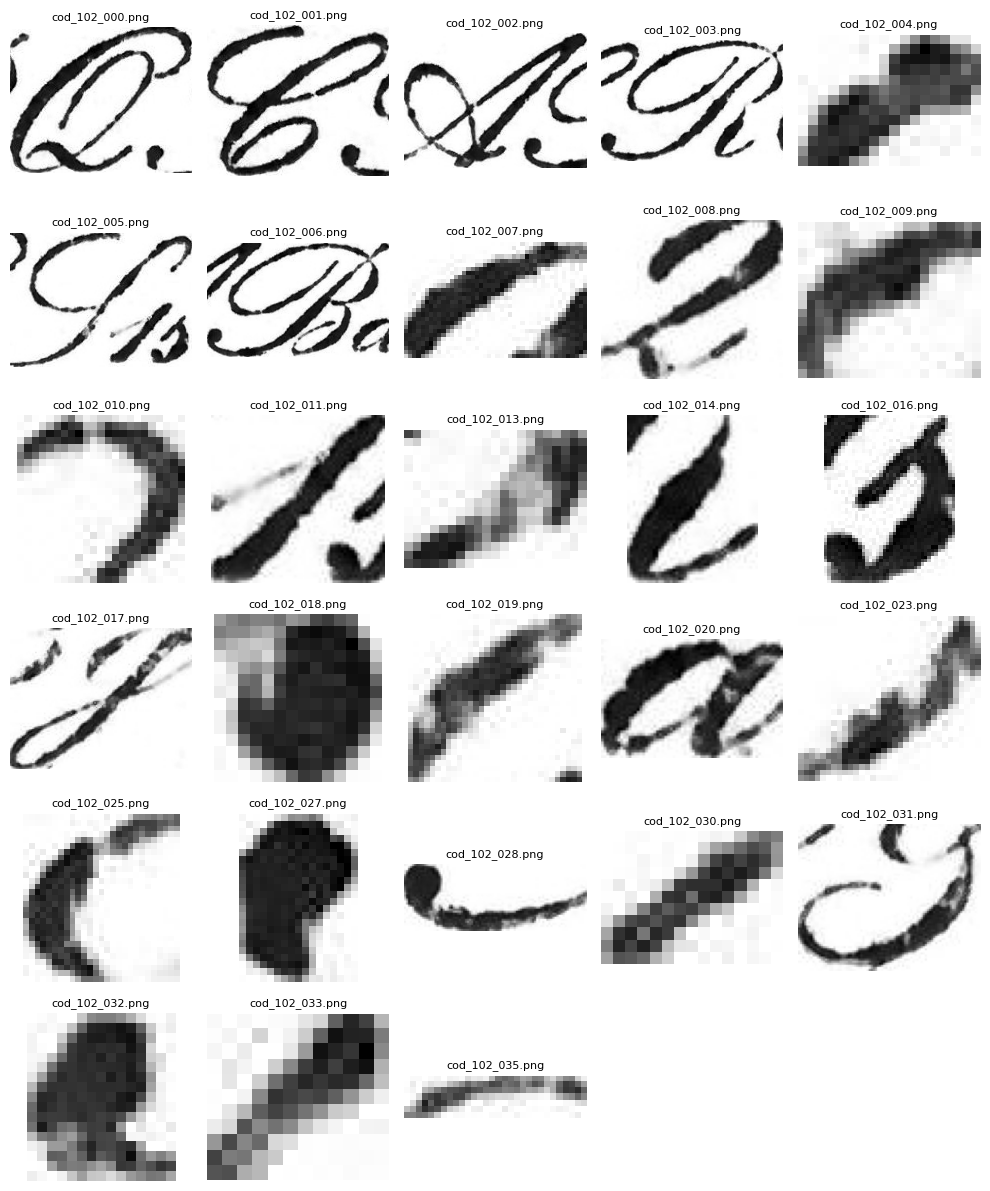

In [14]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/escritural/cod_102')

`cod_113`

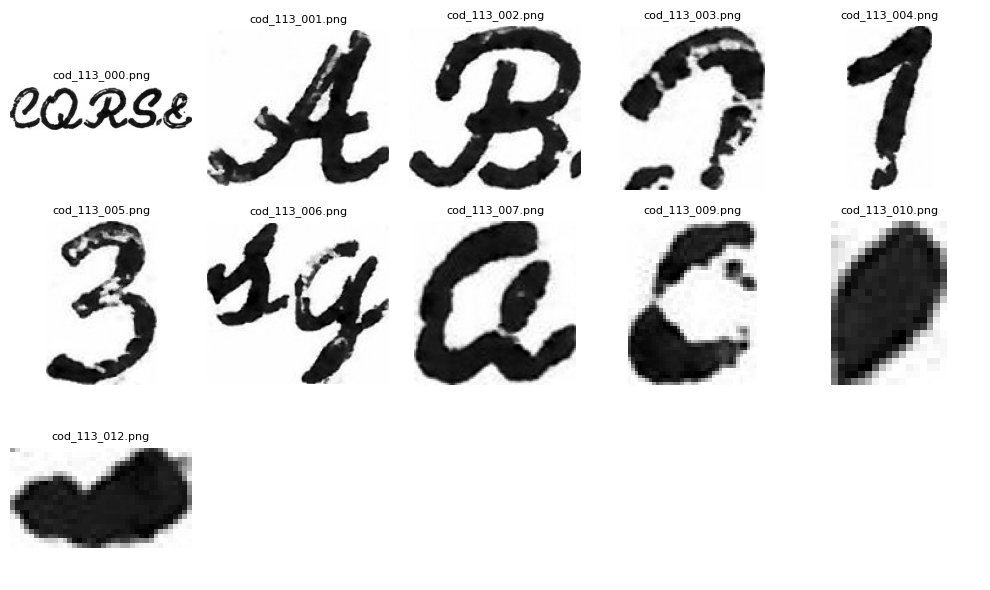

In [16]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/escritural/cod_113')

`cod_115`

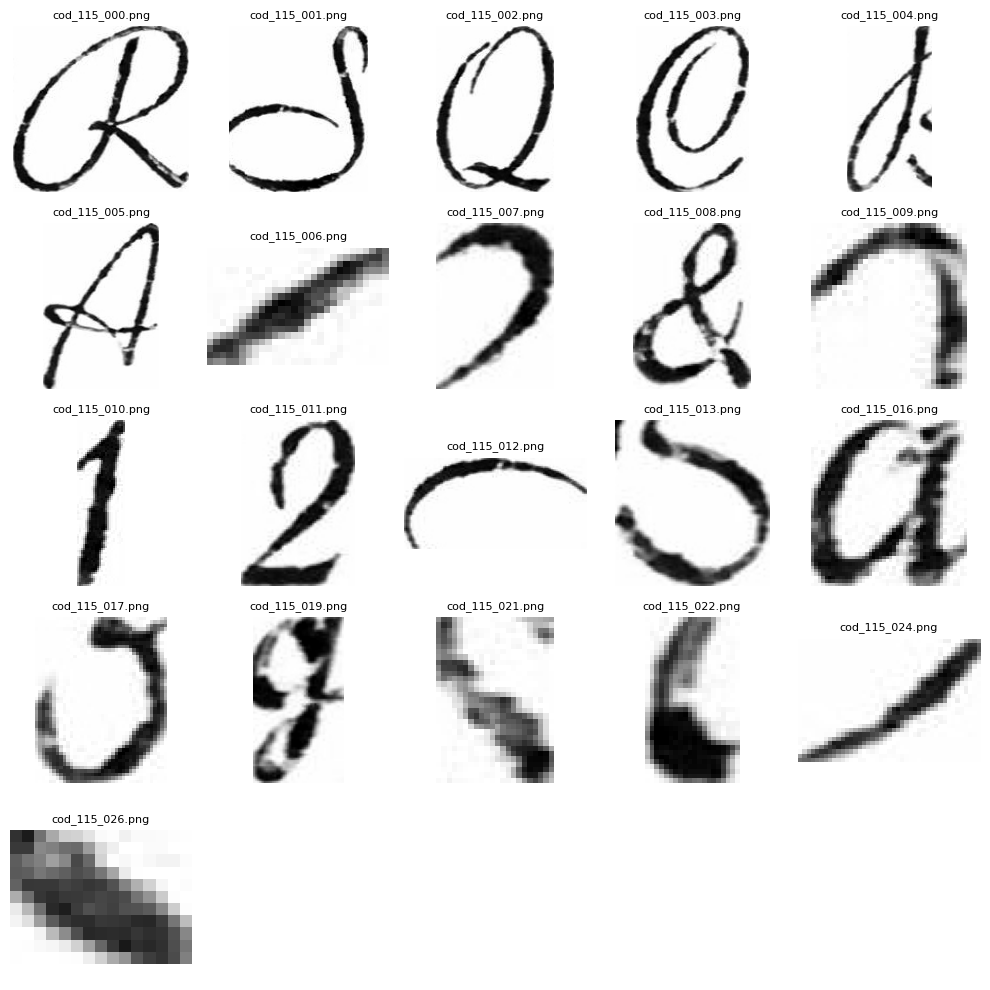

In [17]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/escritural/cod_115')

`cod_109`

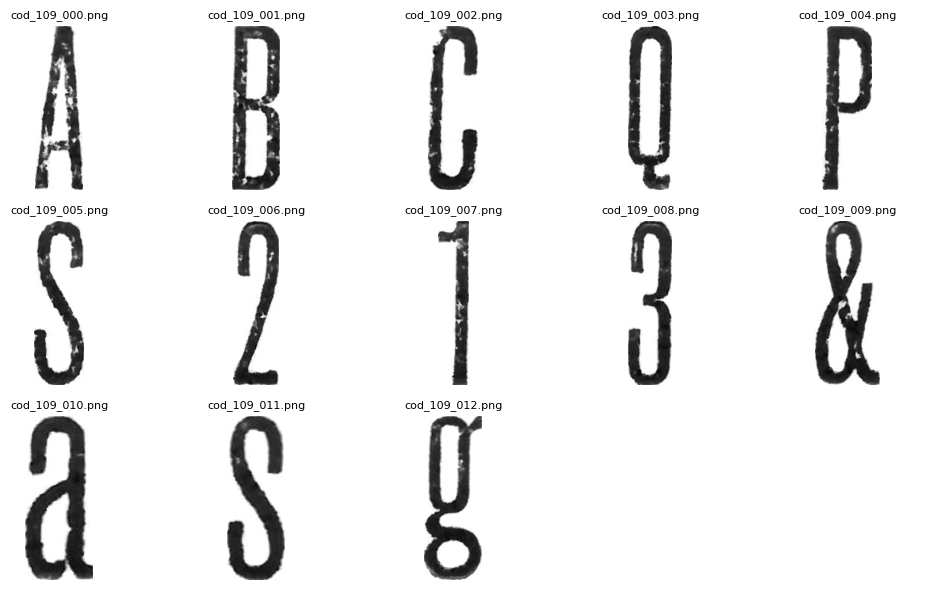

In [18]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/grotesco/cod_109')

`cod_121`

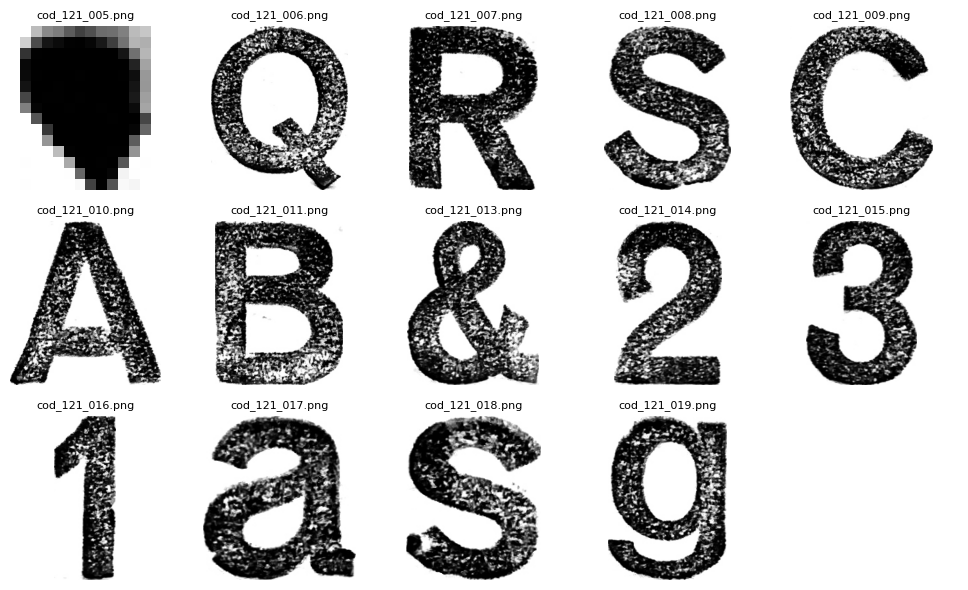

In [19]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/grotesco/cod_121')

`cod_126`

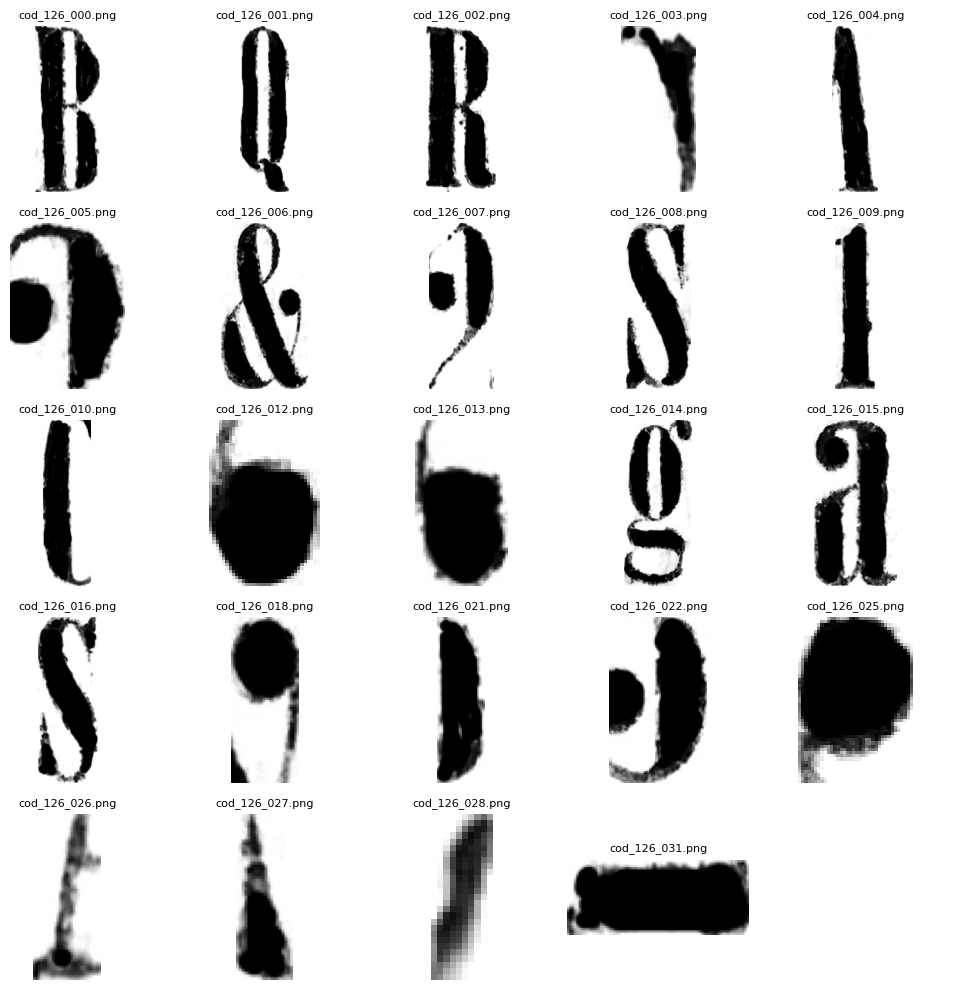

In [20]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/serifado/cod_126')

`cod_108`

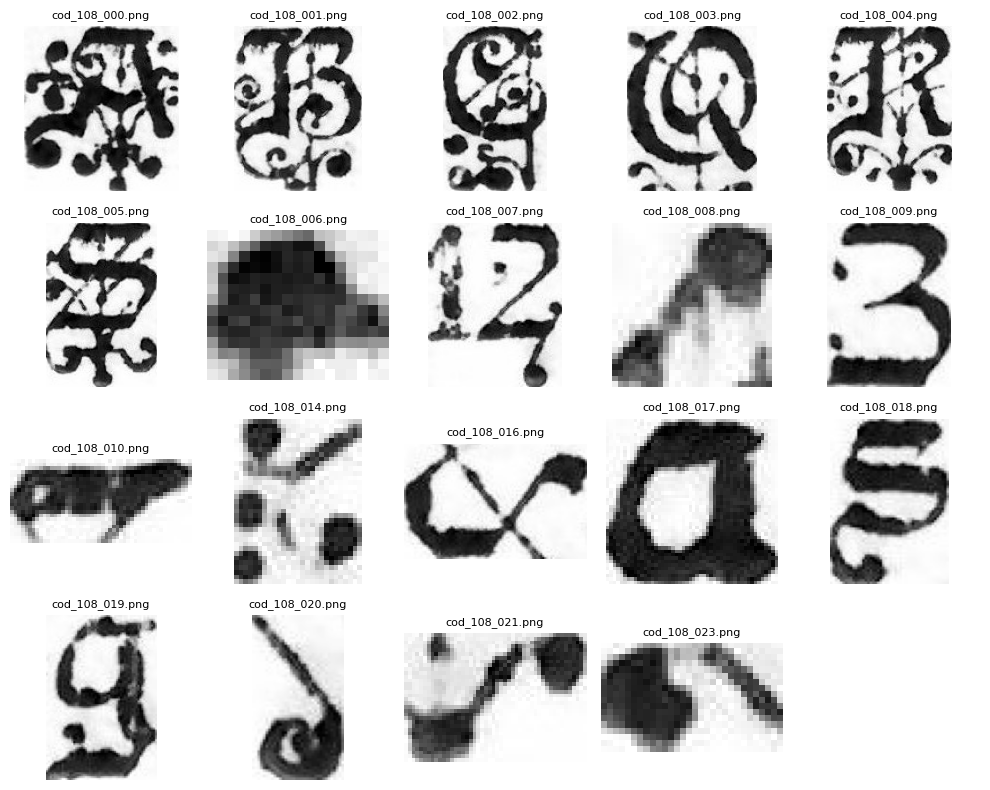

In [21]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/fantasia/cod_108')

`cod_105`

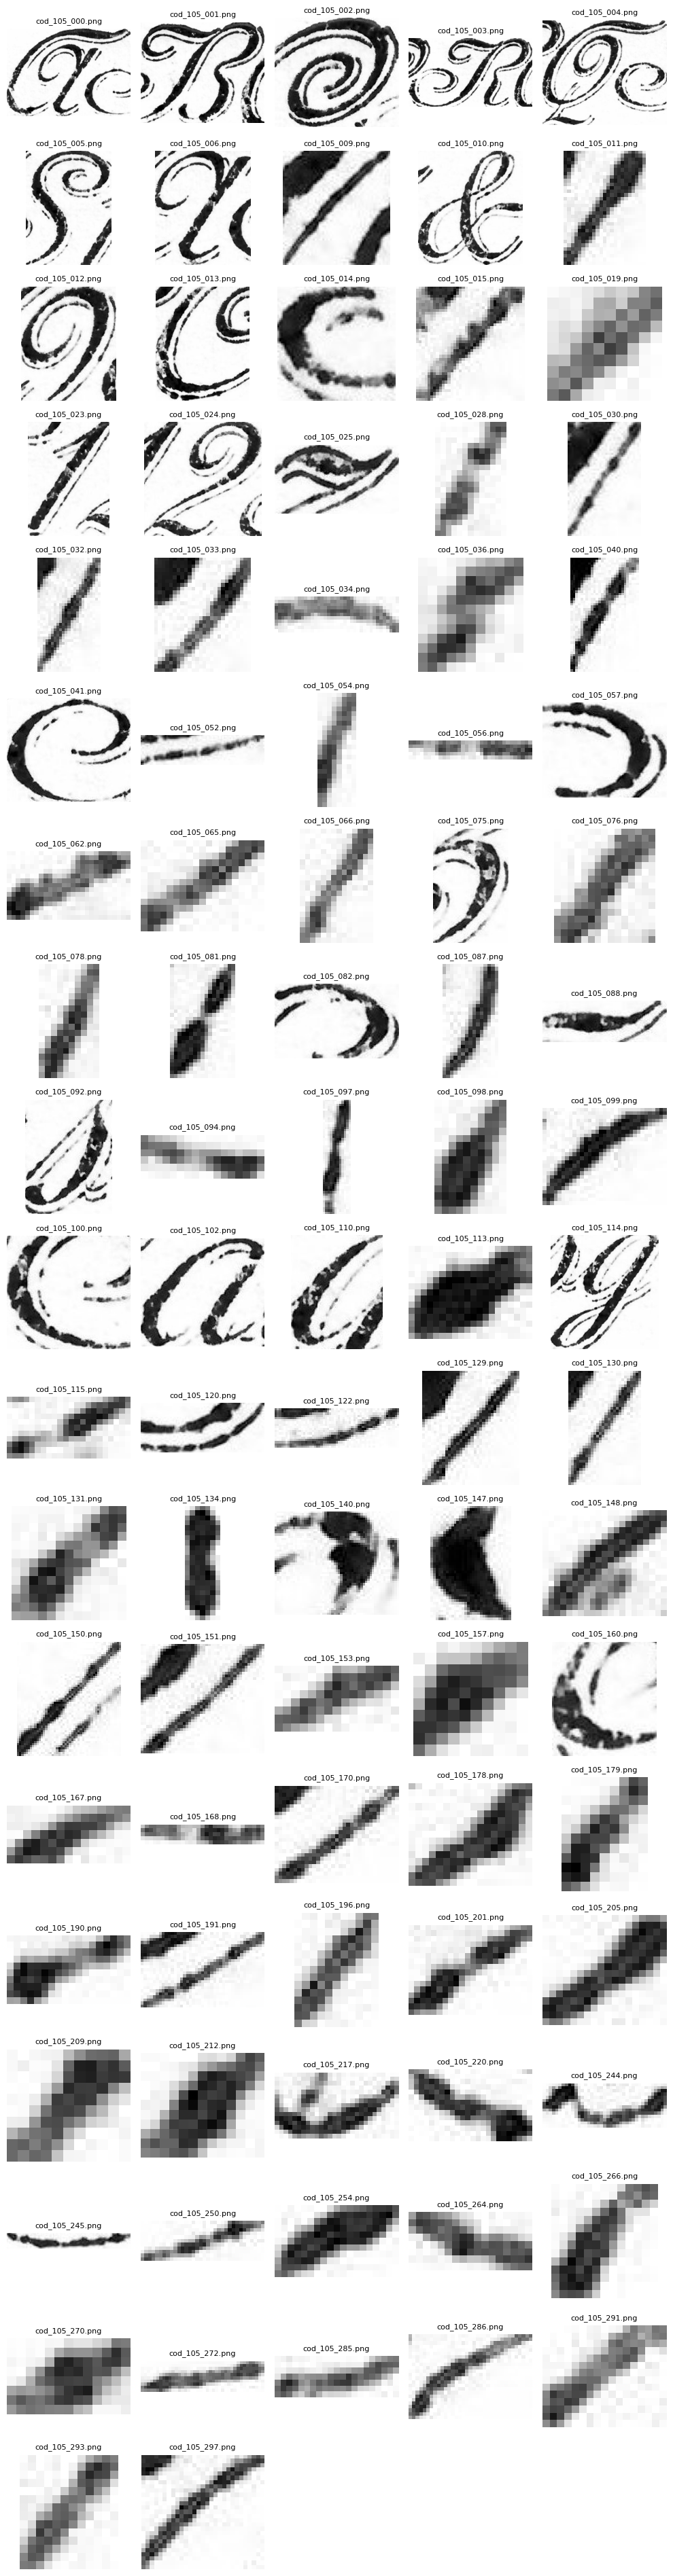

In [22]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/fantasia/cod_105')